# PCA, Clustering and Embeddings

Today we'll analyse the BBC News Articles dataset.

We will turn each article into an embedding, a numeric location on a high-dimensional meaning map, reduce those embeddings with PCA, and use them for clustering and classification.


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import urllib

np.random.seed(42)

pd.set_option("display.max_colwidth", 200)

from sentence_transformers import SentenceTransformer


## The data

[BBC News Articles](https://huggingface.co/datasets/SetFit/bbc-news)

In [36]:
df = pd.read_csv("https://huggingface.co/datasets/SetFit/bbc-news/resolve/main/bbc-text.csv")

In [37]:
df.sample(10)

,category,text
414,politics,brown and blair face new rift claims for the umpteenth time tony blair and gordon brown are said to have declared all out war on each other. this time the alleged rift is over who should take th...
420,business,small firms hit by rising costs rising fuel and materials costs are hitting confidence among the uk s small manufacturers despite a rise in output business lobby group the cbi says. a cbi quar...
1644,entertainment,spirit awards hail sideways the comedy sideways has dominated this year s independent spirit awards winning all six of the awards for which it was nominated. it was named best film while alexand...
416,tech,microsoft releases patches microsoft has warned pc users to update their systems with the latest security fixes for flaws in windows programs. in its monthly security bulletin it flagged up eigh...
1232,sport,arsenal through on penalties arsenal win 4-2 on penalties the spanish goalkeeper saved from alan quinn and jon harley as arsenal sealed a quarter-final trip to bolton with a 4-2 victory on penalt...
1544,business,jobs go at oracle after takeover oracle has announced it is cutting about 5 000 jobs following the completion of its $10.3bn takeover of its smaller rival peoplesoft last week. the company said i...
1748,business,id theft surge hits us consumers almost a quarter of a million us consumers complained of being targeted for identity theft in 2004 official figures suggest. the federal trade commission said tw...
1264,sport,poll explains free-kick decision referee graham poll said he applied the laws of the game in allowing arsenal striker thierry henry s free-kick in sunday s 2-2 draw with chelsea. keeper petr cech...
629,sport,parmar ruled out of davis cup tie a knee injury has forced arvind parmar out of great britain s davis cup tie in israel and left alex bogdanovic in line to take the second singles place. parmar p...
1043,tech,video phones act as dating tools technologies from e-mail to net chatrooms instant messaging and mobiles have proved to be a big pull with those looking for love. the lure once was that you c...


In [4]:
df.value_counts("category")

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [5]:
df.sample()["text"].values[0]

'mourinho receives robson warning sir bobby robson has offered chelsea boss jose mourinho some advice on coping under pressure.  the pair worked together at barcelona and porto and robson had a word of warning for his protege.  it has all gone for him just lately and that is marvellous  but sometimes you have to have a bit of humility and learn how to lose   said robson.  it is when it goes against you and you get a bit of bad luck that you learn  and he ll get it straight.  robson was speaking after being formally granted the freedom of the city of newcastle.  jose is doing very well at the moment   robson added of the man who worked for him for six years.  he has got one pot - possibly two to follow - a big game against barcelona to come and i cannot see them losing their lead in the premiership.  they are in a good position and i would expect them to go on and win it  which is a wonderful achievement.   what has occurred over the last couple of weeks will stand him in very good stea

## Embeddings

An embedding is a numeric representation of a piece of text. You can also think of it as a representation of that text in a multidimensional space. Articles with similar meaning should end up close together, and very different articles should end up far apart.


In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
embeddings = model.encode(df['text'].tolist(), show_progress_bar=True)

emb_df = pd.DataFrame(embeddings)


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

In [8]:
# If above cell takes too long to run, use the precomputed embeddings
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/embeddings.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    emb_df = pd.read_csv(response, index_col=0)


In [9]:
df.iloc[0]["text"]

'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to high

In [10]:
df.iloc[0]["category"]

'tech'

In [11]:
emb_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.001554,-0.067275,0.011174,-0.097146,0.054098,0.042254,-0.034863,-0.017126,0.062448,-0.024317,...,0.083276,-0.012365,0.099596,-0.002854,0.030708,0.069352,-0.008165,-0.015212,-0.063724,0.084557
1,-0.083547,0.059484,-0.013196,-0.011908,0.011631,0.002616,0.117315,0.002310,0.013166,0.028018,...,0.056850,-0.037205,0.039960,0.014939,-0.075912,-0.010551,0.011098,-0.093159,-0.002457,0.021243
2,-0.055962,-0.008481,-0.025843,-0.056737,-0.045265,-0.021684,0.030081,-0.013983,0.030562,-0.003697,...,0.014019,-0.006897,-0.006589,-0.018533,-0.056650,-0.000594,0.039833,-0.056027,0.043895,-0.046996
3,0.015004,-0.125696,-0.028034,-0.040649,0.080588,0.052048,0.025743,-0.012287,0.033973,0.002043,...,0.004305,-0.004015,-0.057729,-0.021071,0.009793,0.056244,-0.032304,-0.020664,-0.025317,0.056185
4,-0.018273,-0.018895,-0.047967,-0.070612,-0.006405,0.059953,-0.119612,0.026853,0.050197,-0.011960,...,0.051296,0.027649,-0.022006,-0.028721,-0.003901,0.082542,-0.065968,-0.073110,-0.035203,0.043847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,-0.027352,-0.026011,0.054015,0.025434,-0.014118,0.073263,-0.022070,0.068582,-0.033815,-0.002269,...,-0.010152,-0.027655,-0.055435,-0.022257,-0.029578,-0.062166,-0.029384,-0.129902,-0.041675,0.080504
2221,-0.017127,0.009932,0.017573,-0.024224,0.050684,0.034838,0.082775,-0.099431,-0.101437,0.020063,...,0.045735,-0.004506,-0.019301,-0.011101,-0.026871,0.096571,-0.026657,0.012036,-0.049906,0.012583
2222,0.027212,-0.136341,0.026965,-0.063657,-0.002635,0.035392,0.036003,-0.031810,0.021682,0.062556,...,0.032426,0.031709,-0.021834,0.052545,0.000720,0.055665,-0.050568,-0.092031,-0.077371,-0.007813
2223,0.046371,-0.035961,0.065271,-0.032036,0.030133,0.061473,-0.000475,-0.001458,0.036582,0.081157,...,0.069588,0.028942,0.002779,-0.033584,-0.061675,0.092261,0.012804,0.045767,-0.016248,0.048731


In [12]:
emb_df.iloc[0].tolist()

[-0.001553876,
 -0.06727469,
 0.011174214,
 -0.09714647,
 0.05409849,
 0.042253822,
 -0.03486287,
 -0.017126063,
 0.062448256,
 -0.024316564,
 -0.04787935,
 0.045247436,
 -0.01705424,
 -0.015675152,
 0.013085875,
 -0.1557984,
 0.07755032,
 -0.12457919,
 -0.007810337,
 0.023632307,
 -0.013241261,
 -0.055903994,
 -0.052496992,
 -0.004659107,
 0.05348777,
 -0.022686033,
 -0.06298673,
 0.0005361094,
 -0.0037238155,
 -0.030825287,
 -0.0024546355,
 0.03775705,
 0.013111599,
 0.044811916,
 -0.07275285,
 -0.039356403,
 0.00037462913,
 -0.004450885,
 -0.10191604,
 0.0017646332,
 0.06019026,
 -0.09947903,
 -0.009305393,
 -0.061449282,
 -0.0027737643,
 0.040667787,
 0.021240814,
 -0.040535644,
 -0.07212074,
 -0.0015725094,
 -0.0652869,
 0.030321548,
 0.06136828,
 0.020016698,
 -0.021162895,
 -0.0056913635,
 0.047824703,
 0.08727437,
 -0.0030796633,
 0.029061183,
 -0.0060282955,
 -0.041554086,
 -0.028440239,
 0.036712542,
 -0.015836779,
 0.03216546,
 0.066254795,
 0.11543839,
 0.021183234,
 -0.072

## Tasks


### Task 1

Use distances between embeddings to find articles that are most similar to random article from a dataset.

For distances, you can use [sklearn.metrics.pairwise_distances](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html). Are the articles similar?


In [13]:
from sklearn.metrics import pairwise_distances

article_index = np.random.choice(range(0, len(df)))

In [14]:
distances = pairwise_distances(emb_df.iloc[[article_index]], emb_df, metric="euclidean")
distances


array([[1.38171595, 1.21412082, 1.22555625, ..., 1.36570453, 1.24112952,
        1.30960468]], shape=(1, 2225))

In [15]:
df["distance_to_article"] = distances[0]

df.sort_values("distance_to_article").head(5)

,category,text,distance_to_article
1334,politics,clarke defends terror detentions the home secretary has defended his decision not to release foreign terror suspects despite a legal ruling their detention breached human rights laws. house of lo...,2.107342e-08
542,politics,act on detention ruling uk urged the government must act quickly on the law lords ruling that detention of foreign terror suspects without trial is unlawful mary robinson has said. the former ...,6.083114e-01
2018,politics,uk plan to deport terror suspects deals are being sought to allow the uk to deport terror suspects to their home countries without risk of them being tortured or sentenced to death. home secretar...,6.112674e-01
1280,politics,lords wrong on detainees - straw jack straw has attacked the decision by britain s highest court that detaining foreign terrorist suspects without trial breaks human rights laws. the foreign secr...,6.612165e-01
1529,politics,terror detainees win lords appeal detaining foreign terrorist suspects without trial breaks human rights laws the uk s highest court has ruled. in a blow to the government s anti-terror measures...,6.647774e-01


### Task 2

PCA reduces many embedding features down to two components so we can visualize them.

- Reduce the dimensions of the embeddings dataset to two principal components.
- Assign the principal component values to the original dataframe `df`.
- Plot the result on a scatterplot.


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(emb_df)
embeddings_pca

array([[-0.33302767, -0.11366943],
       [-0.00167386,  0.04047141],
       [ 0.35546257, -0.004579  ],
       ...,
       [ 0.13618775, -0.15783533],
       [ 0.11855819,  0.36445237],
       [ 0.39489676,  0.00635914]], shape=(2225, 2))

In [17]:
df["pc1"] = embeddings_pca[:, 0]
df["pc2"] = embeddings_pca[:, 1]

df.head()

,category,text,distance_to_article,pc1,pc2
0,tech,tv future in the hands of viewers with home theatre systems plasma high-definition tvs and digital video recorders moving into the living room the way people watch tv will be radically differen...,1.381716,-0.333028,-0.113669
1,business,worldcom boss left books alone former worldcom boss bernie ebbers who is accused of overseeing an $11bn (£5.8bn) fraud never made accounting decisions a witness has told jurors. david myers ...,1.214121,-0.001674,0.040471
2,sport,tigers wary of farrell gamble leicester say they will not be rushed into making a bid for andy farrell should the great britain rugby league captain decide to switch codes. we and anybody else...,1.225556,0.355463,-0.004579
3,sport,yeading face newcastle in fa cup premiership side newcastle united face a trip to ryman premier league leaders yeading in the fa cup third round. the game - arguably the highlight of the draw - i...,1.302503,0.379490,0.074699
4,entertainment,ocean s twelve raids box office ocean s twelve the crime caper sequel starring george clooney brad pitt and julia roberts has gone straight to number one in the us box office chart. it took $4...,1.350938,-0.254141,-0.256651


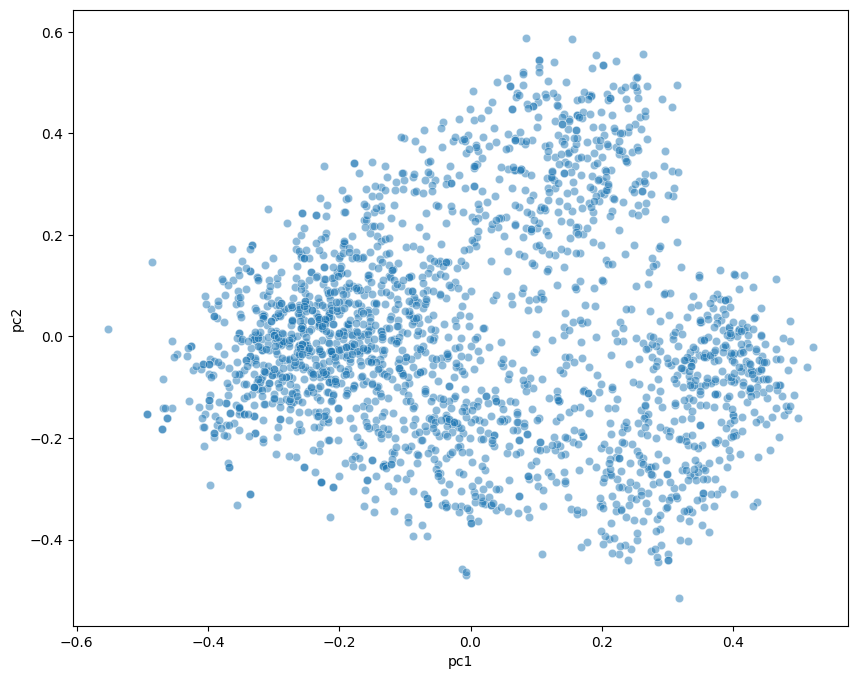

In [18]:
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=df,
    x="pc1",
    y="pc2",
    alpha=0.5,
)

### Task 3

Print out several articles that are close to one another on the scatterplot above. Is their content similar?


In [19]:
tmp = df[
    df["pc1"].between(-0.1, 0.1) &
    df["pc2"].between(-0.5, -0.4)
]

for index, row in tmp.iterrows():
    print(row["category"])
    print(row["text"])
    print("-" * 100)


entertainment
sideways dominates spirit awards the comedy sideways has dominated this year s independent spirit awards  winning all six of the awards for which it was nominated.  it was named best film while alexander payne won best director and best screenplay  along with writing partner jim taylor. it also won acting awards for stars paul giamatti  thomas haden church and virginia madsen. sideways is tipped to do well at sunday s oscars  with five nominations.  the awards  now in their 20th year  are given to films made outside the traditional studio system  and are traditionally held the day before the oscars. other winners included catalina sandino moreno  who took best actress for her role as a drug smuggler in the colombian drama maria full of grace. moreno is also nominated for best actress at the oscars. the best first screenplay award went to joshua marston for maria full of grace. scrubs star zach braff won the award for best first feature for garden state  which he wrote  di

### Task 4

Apply k-means clustering.

- Cluster the articles into three clusters using k-means clustering.
- Visualize the clusters on a scatterplot.
- Do the clusters have something in common in terms of article category?


<Axes: xlabel='pc1', ylabel='pc2'>

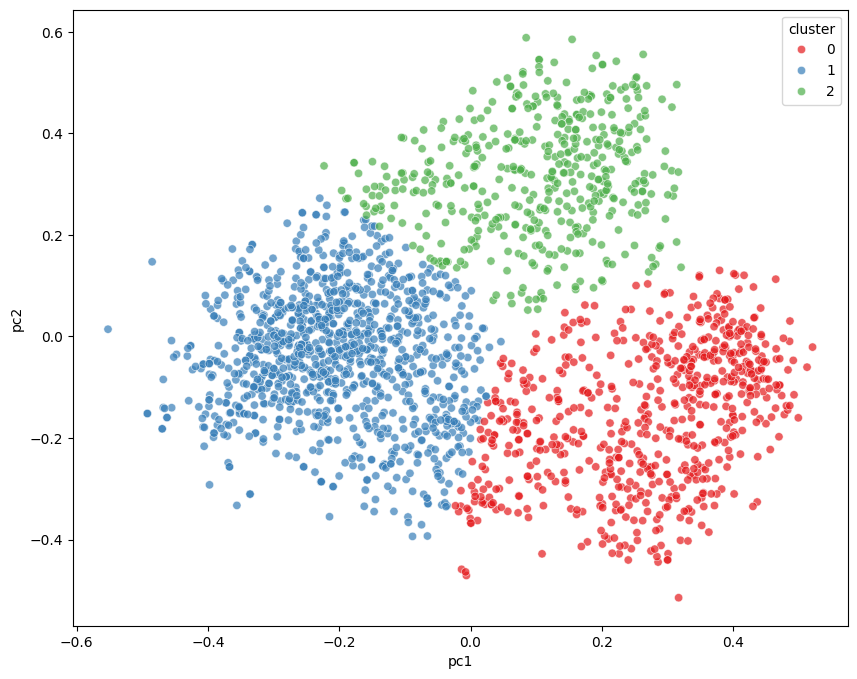

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(df[["pc1", "pc2"]])

df['cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x="pc1", 
    y="pc2", 
    hue="cluster",
    palette="Set1",
    alpha=0.7
)


In [21]:
df.groupby(["cluster", "category"]).size()

cluster  category     
0        entertainment    146
         politics           3
         sport            505
         tech               5
1        business         455
         entertainment    237
         politics          13
         tech             394
2        business          55
         entertainment      3
         politics         401
         sport              6
         tech               2
dtype: int64

<Axes: xlabel='pc1', ylabel='pc2'>

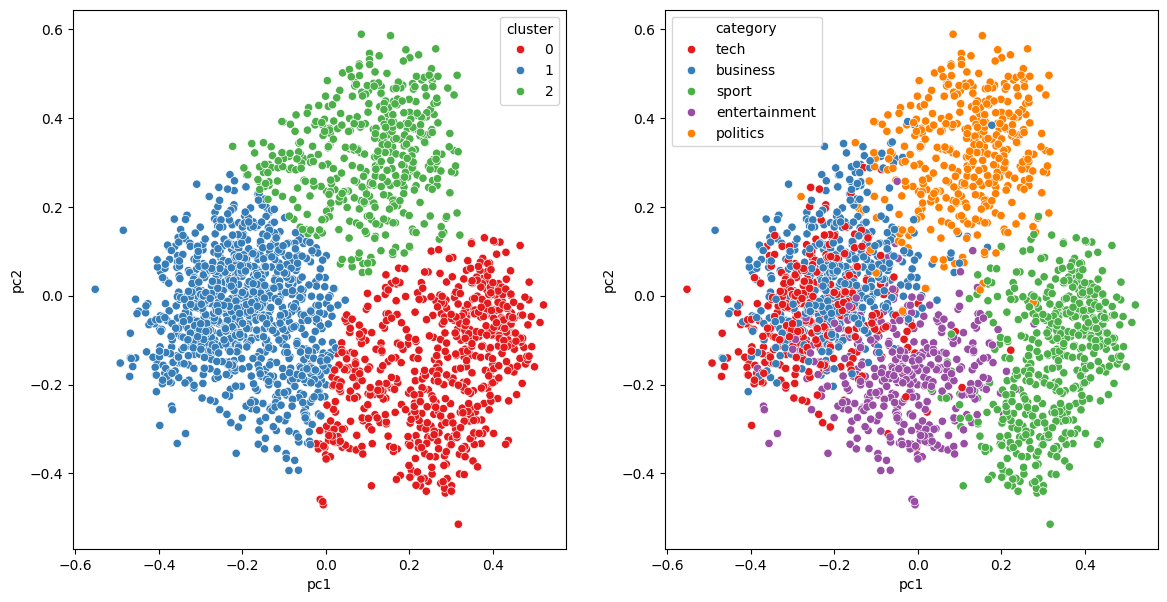

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

sns.scatterplot(
    data=df,
    x="pc1", 
    y="pc2", 
    hue="cluster",
    palette="Set1",
    ax=axs[0]
)

sns.scatterplot(
    data=df,
    x="pc1", 
    y="pc2", 
    hue="category",
    palette="Set1",
    ax=axs[1]
)


### Task 5

Find the optimal number of clusters via the Elbow method.

Text(0, 0.5, 'inertia')

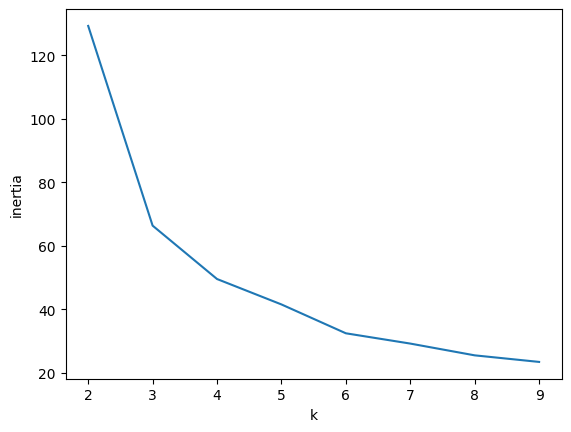

In [23]:
ks = range(2, 10)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[["pc1", "pc2"]])
    inertias.append(kmeans.inertia_)

ax = sns.lineplot(x=ks, y=inertias)
ax.set_xlabel("k")
ax.set_ylabel("inertia")


### Task 6

Fit kmeans with another value for `n_clusters` and visualize the clusters. Show which article categories belong to the clusters and interpret.




<Axes: xlabel='pc1', ylabel='pc2'>

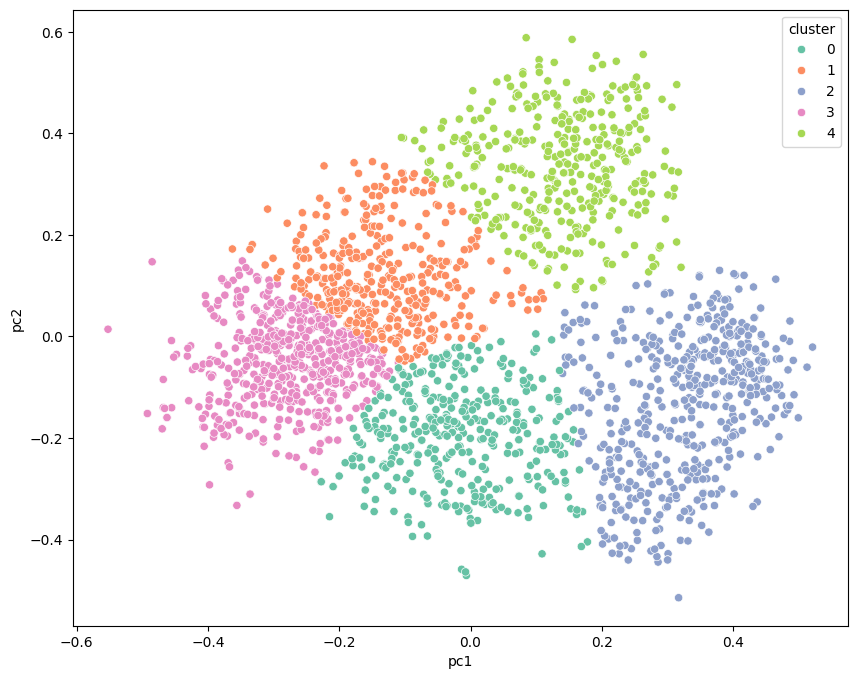

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6)
clusters = kmeans.fit_predict(df[["pc1", "pc2"]])

df['cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x="pc1", 
    y="pc2", 
    hue="cluster",
    palette="Set2"
)


In [25]:
df.groupby(["cluster", "category"]).size()

cluster  category     
0        business          13
         entertainment    301
         politics           1
         sport             25
         tech              39
1        business         243
         entertainment     15
         politics          50
         tech              77
2        entertainment     21
         politics           3
         sport            480
         tech               1
3        business         243
         entertainment     48
         tech             284
4        business          11
         entertainment      1
         politics         363
         sport              6
dtype: int64

### Task 7

Repeat the PCA + clustering workflow in three dimensions.

- Reduce the embedding dataset to three principal components.
- Find optimal number of clusters.
- Fit k-means with that number of clusters.
- Visualize the result with a Plotly 3D scatterplot.


Text(0.5, 1.0, 'Elbow method on 3D PCA features')

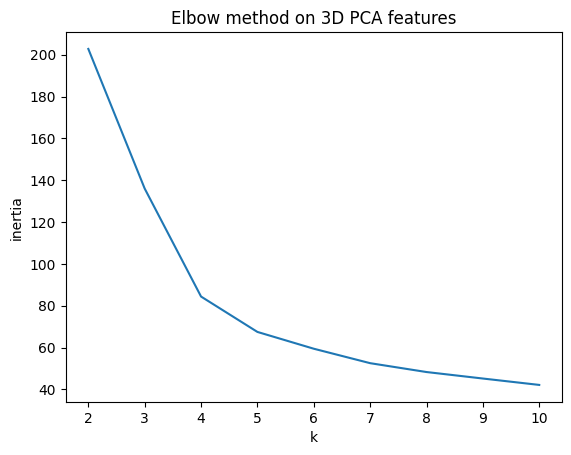

In [ ]:
pca_3d = PCA(n_components=3)
embeddings_pca_3d = pca_3d.fit_transform(emb_df)

df["pc1"] = embeddings_pca_3d[:, 0]
df["pc2"] = embeddings_pca_3d[:, 1]
df["pc3"] = embeddings_pca_3d[:, 2]

ks = range(2, 10)
inertias_3d = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(df[["pc1", "pc2", "pc3"]])
    inertias_3d.append(kmeans.inertia_)

ax = sns.lineplot(x=list(ks), y=inertias_3d)
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("Elbow method on 3D PCA features")


In [27]:
import plotly.express as px

optimal_k_3d = 4

kmeans_3 = KMeans(n_clusters=optimal_k_3d)
df["cluster"] = kmeans_3.fit_predict(df[["pc1", "pc2", "pc3"]]).astype('str')

fig = px.scatter_3d(
    df,
    x="pc1",
    y="pc2",
    z="pc3",
    color="cluster",
)

fig.update_traces(marker={"size": 3})
fig.update_layout(width=1000, height=800)

fig.show()


### Task 8

Now we use the embedding coordinates as input features for a supervised model.

Train a model (RandomForest or LogisticRegression) for predicting whether an article belongs to the politics category. The model `pipeline` should take the full embedding as input and perform PCA before feeding it into the next steps of the pipeline. You should also perform hyperparameter tuning for n_components in PCA and one other hyperparameter.

Report the performance of the model on the test set:
- Report the performance metrics;
- Do some error analysis - what do you notice about the false positives and false negatives in terms of content and their categories?

Hint: you can use PCA in a scikit-learn pipeline just like you would e.g. `PolynomialFeatures`.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures

y = df["category"] == "politics"
X = emb_df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [29]:
model = Pipeline([
    ("pca", PCA(n_components=10)),
    ("poly", PolynomialFeatures(degree=2)),
    ("logreg", LogisticRegression())
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logreg__C": [10**i for i in range(-6, 6)],
    "logreg__class_weight": [None, "balanced"],
    "pca__n_components": [4, 15]
}

grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
grid_search.best_params_


{'logreg__C': 100, 'logreg__class_weight': 'balanced', 'pca__n_components': 15}

In [31]:
from sklearn.metrics import classification_report

In [32]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.98      0.99      0.99       365
        True       0.97      0.93      0.95        80

    accuracy                           0.98       445
   macro avg       0.98      0.96      0.97       445
weighted avg       0.98      0.98      0.98       445



In [33]:
errors = df.loc[y_test.index].copy()
errors["actual_politics"] = y_test
errors["predicted_politics"] = y_pred

false_positive = errors[(~errors["actual_politics"]) & (errors["predicted_politics"])].sample(1).iloc[0]
false_negative = errors[(errors["actual_politics"]) & (~errors["predicted_politics"])].sample(1).iloc[0]

print("False positive")
print(false_positive["category"])
print(false_positive["text"])
print()
print("False negative")
print(false_negative["category"])
print(false_negative["text"])

False positive
business
golden rule  intact  says ex-aide chancellor gordon brown will meet his golden economic rule  with a margin to spare   according to his former chief economic adviser.  formerly one of mr brown s closest treasury aides  ed balls hinted at a budget giveaway on 16 march. he said he hoped more would be done to build on current tax credit rules. any rate rise ahead of an expected may election would not affect the labour party s chances of winning  he added. last july  mr balls won the right to step down from his treasury position and run for parliament  defending the labour stronghold of normanton in west yorkshire.  mr balls rejected the allegation that mr brown had been sidelined in the election campaign  saying he was playing a  different  role to the one he played in the last two elections. he rejected speculation that mr brown was considering becoming foreign secretary  saying his recent travels had been linked to efforts to boost international development. gord

## Rest of the Course

- Two intensive weeks in May.
- Will upload the last homework today or tomorrow.
- Will share information about group project consultations next week.
